In [10]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("erogluegemen/airline-passengers")
print("Dataset downloaded to:", path)

Dataset downloaded to: /Users/aymnouha/.cache/kagglehub/datasets/erogluegemen/airline-passengers/versions/1


In [11]:
import pandas as pd
import os

files = os.listdir(path)
print("Fichiers disponibles :", files)

csv_path = os.path.join(path, "airline-passengers.csv")

data = pd.read_csv(csv_path)

# Afficher les 5 premières lignes
print(data.head())

Fichiers disponibles : ['airline-passengers.csv']
     month  total_passengers
0  1949-01               112
1  1949-02               118
2  1949-03               132
3  1949-04               129
4  1949-05               121


In [12]:
data['month'] = pd.to_datetime(data['month'])
data.set_index('month', inplace=True)

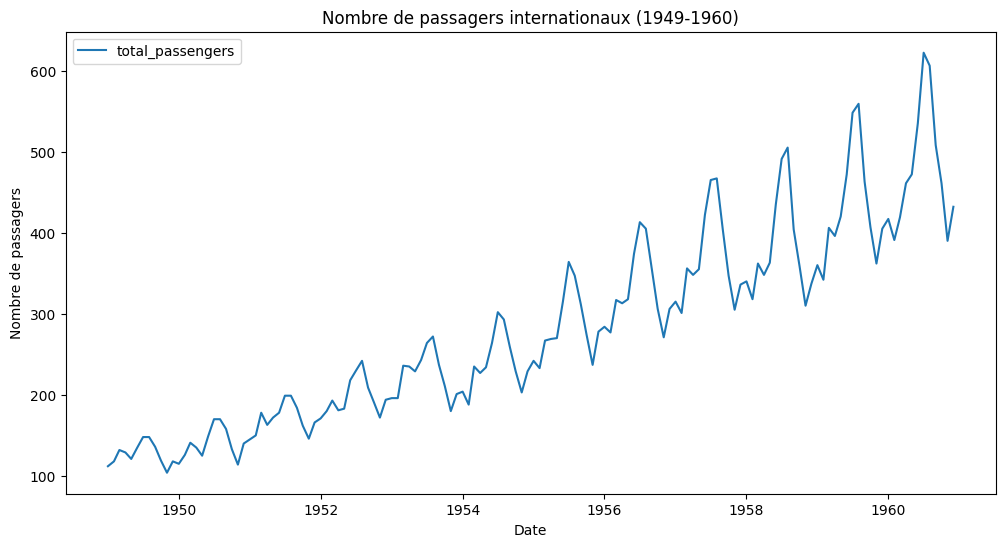

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data, label="total_passengers")
plt.title("Nombre de passagers internationaux (1949-1960)")
plt.xlabel("Date")
plt.ylabel("Nombre de passagers")
plt.legend()
plt.show()


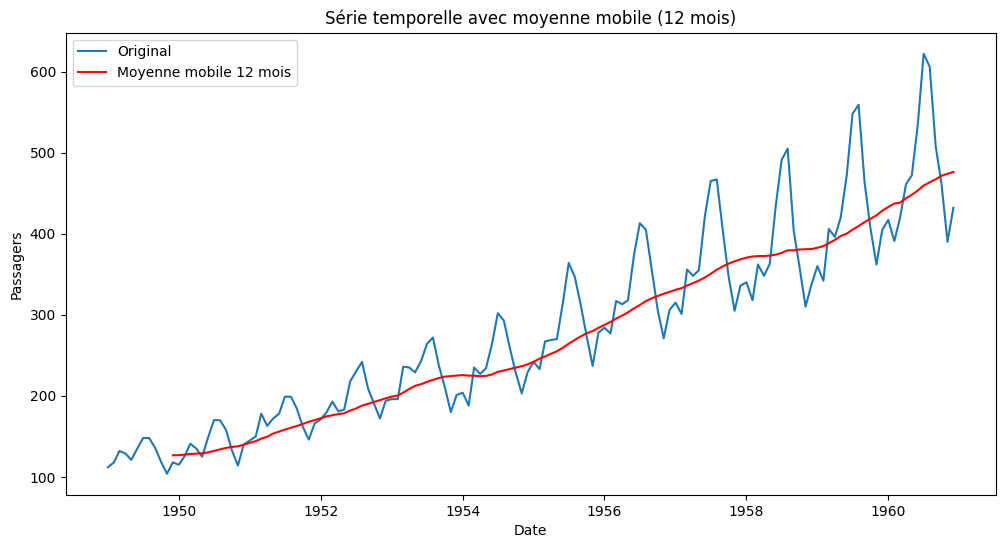

In [14]:
data['MA12'] = data['total_passengers'].rolling(window=12).mean()

plt.figure(figsize=(12,6))
plt.plot(data['total_passengers'], label="Original")
plt.plot(data['MA12'], label="Moyenne mobile 12 mois", color='red')
plt.title("Série temporelle avec moyenne mobile (12 mois)")
plt.xlabel("Date")
plt.ylabel("Passagers")
plt.legend()
plt.show()

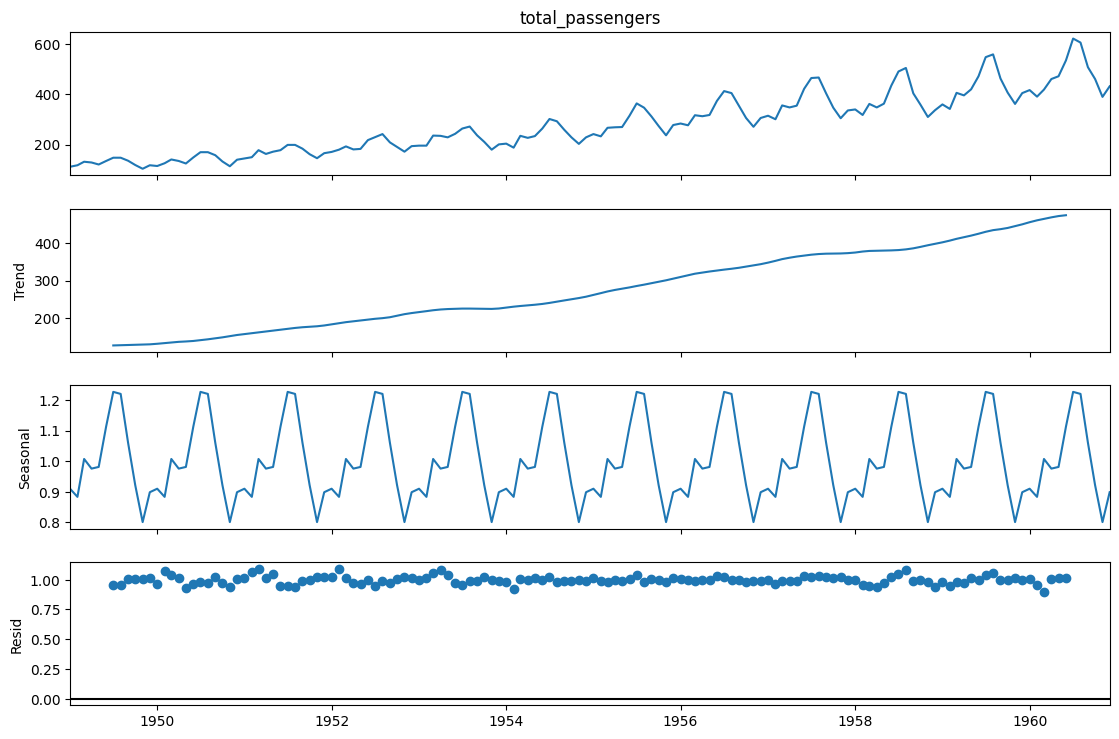

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(data['total_passengers'], model='multiplicative', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()